# Gradient Descent in One Variable — Part 3 (Pitfalls)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on the practical difficulties of
**gradient descent** (Week 2 — Gradients and Gradient Descent).

This notebook covers the two main pitfalls:

- **choosing the learning rate** — too large overshoots, too small crawls, "just right"
  is hard (a genuine research problem)
- **local minima** — gradient descent can get stuck at a point that *looks* like the
  minimum but isn't the global one
- the practical fix: **random restarts** (run from many starting points)

Each issue comes with a runnable demonstration. This notebook follows the repository
`GUIDELINES.md` template and continues directly from
*Gradient Descent in One Variable — Part 2*.

## 1. Introduction

The update rule from Part 2,

$$
x_k = x_{k-1} - \alpha\, f'(x_{k-1}),
$$

is simple, but two things make it tricky in practice:

> *"Learning rate is a big deal in machine learning, and finding a good learning rate can
> be pretty hard... Here's another problem: gradient descent may take you to a local
> minimum."*

After this notebook you will be able to:

- describe the failure modes of a poorly chosen learning rate
- recognize the local-minimum trap
- apply random restarts to improve your chances of finding the global minimum

## 2. The learning rate $\alpha$

> *"If the learning rate is too large, you may miss the minimum and never find it. If it's
> too small, you may take forever or never reach it. What you want is one that's just
> right — but finding it can be pretty hard."*

Three regimes:

- **Too large** → steps overshoot; the iterates oscillate or **diverge**.
- **Too small** → progress is painfully **slow**.
- **Just right** → fast, stable convergence.

> *"It's actually a research problem to find a good learning rate."* There are adaptive
> methods that change $\alpha$ during training, but no single definitive rule.

We illustrate on the simple bowl $f(x) = x^2$, where $f'(x) = 2x$ and the minimum is at
$x = 0$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent(fprime, x0, alpha, n_steps=50):
    x = x0
    hist = [x]
    for _ in range(n_steps):
        x = x - alpha * fprime(x)
        hist.append(x)
    return np.array(hist)

fprime_bowl = lambda x: 2*x   # f(x) = x^2

paths = {
    "too small  α=0.01": gradient_descent(fprime_bowl, 5.0, 0.01),
    "just right α=0.3":  gradient_descent(fprime_bowl, 5.0, 0.3),
    "too large  α=1.01": gradient_descent(fprime_bowl, 5.0, 1.01),
}

for name, h in paths.items():
    print(f"{name}:  x after 50 steps = {h[-1]: .4f}")

too small  α=0.01:  x after 50 steps =  1.8208
just right α=0.3:  x after 50 steps =  0.0000
too large  α=1.01:  x after 50 steps =  13.4579


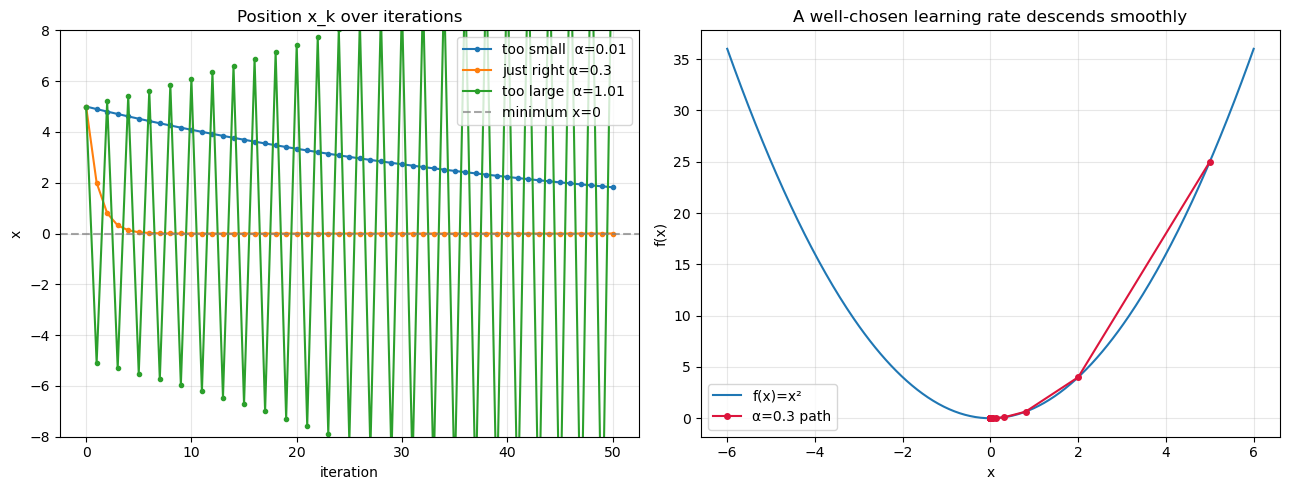

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# value of x over iterations
for name, h in paths.items():
    axes[0].plot(h, "o-", markersize=3, label=name)
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.7, label="minimum x=0")
axes[0].set_title("Position x_k over iterations")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("x")
axes[0].set_ylim(-8, 8)
axes[0].grid(True, alpha=0.3); axes[0].legend()

# steps drawn on the parabola for the "just right" case
xs = np.linspace(-6, 6, 300)
axes[1].plot(xs, xs**2, label="f(x)=x²")
h = paths["just right α=0.3"]
axes[1].plot(h, h**2, "o-", color="crimson", markersize=4, label="α=0.3 path")
axes[1].set_title("A well-chosen learning rate descends smoothly")
axes[1].set_xlabel("x"); axes[1].set_ylabel("f(x)")
axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.show()

## 3. The local-minimum problem

> *"Say the minimum is this one. But if you start your gradient descent over here, it's
> never going to take you to that minimum — it takes you to a local minimum, a point that
> looks like a minimum but isn't."*

Gradient descent only ever moves **downhill** from where it starts, so it lands in the
**nearest valley** — which may be a **local** minimum, not the **global** one.

We use a function with two valleys of different depth:

$$
f(x) = 3x^4 + 4x^3 - 12x^2,\qquad f'(x) = 12x^3 + 12x^2 - 24x = 12x(x+2)(x-1).
$$

Its critical points are $x=-2$ (**global** min), $x=0$ (local max), and $x=1$ (**local**
min).

In [3]:
def f_multi(x):
    return 3*x**4 + 4*x**3 - 12*x**2

def fprime_multi(x):
    return 12*x**3 + 12*x**2 - 24*x

# values at the critical points
for xc in (-2, 0, 1):
    print(f"x = {xc:>2}:  f = {f_multi(xc):>4}  (global min, local max, local min)"
          [: 38] if False else f"x = {xc:>2}:  f = {f_multi(xc):>5}")

x = -2:  f =   -32
x =  0:  f =     0
x =  1:  f =    -5


start x0=-1.0  ->  x = -2.0000  (f = -32.000)
start x0= 0.5  ->  x = 1.0000  (f = -5.000)


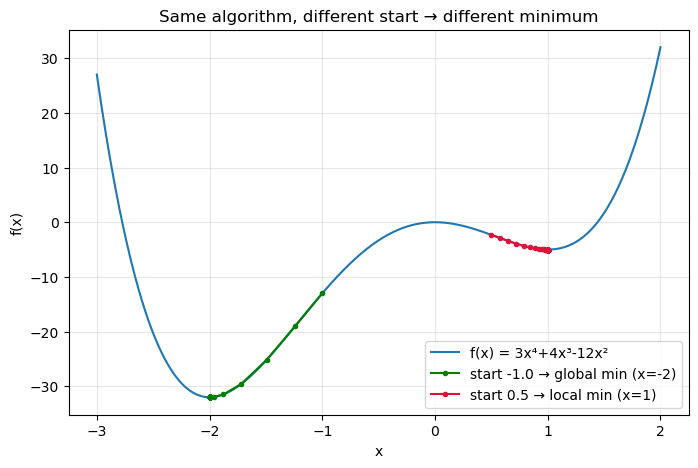

In [4]:
# two runs: one falls into the global min, one into the local min
path_global = gradient_descent(fprime_multi, x0=-1.0, alpha=0.01, n_steps=200)
path_local  = gradient_descent(fprime_multi, x0= 0.5, alpha=0.01, n_steps=200)

print(f"start x0=-1.0  ->  x = {path_global[-1]:.4f}  (f = {f_multi(path_global[-1]):.3f})")
print(f"start x0= 0.5  ->  x = {path_local[-1]:.4f}  (f = {f_multi(path_local[-1]):.3f})")

xs = np.linspace(-3, 2, 400)
plt.figure(figsize=(8, 5))
plt.plot(xs, f_multi(xs), label="f(x) = 3x⁴+4x³-12x²")
plt.plot(path_global, f_multi(path_global), "o-", color="green", markersize=3,
         label="start -1.0 → global min (x=-2)")
plt.plot(path_local, f_multi(path_local), "o-", color="crimson", markersize=3,
         label="start 0.5 → local min (x=1)")
plt.title("Same algorithm, different start → different minimum")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 4. The fix: random restarts

> *"There's actually no secure way to overcome it. But a way to get pretty good results is
> to run gradient descent many times with many different starting points. Chances are one
> of them will get you to the minimum, or at least a pretty good point."*

Run gradient descent from many random starts and keep the **best** result.

In [5]:
def gradient_descent_final(fprime, x0, alpha, n_steps=300):
    x = x0
    for _ in range(n_steps):
        x = x - alpha * fprime(x)
    return x

rng = np.random.default_rng(0)
starts = rng.uniform(-3, 2, size=12)

results = [(gradient_descent_final(fprime_multi, s, 0.01), s) for s in starts]
results = [(x, s) for (x, s) in results if np.isfinite(x)]

best_x, best_start = min(results, key=lambda r: f_multi(r[0]))
print("results from random starts (x_found, f):")
for x_found, s in results:
    print(f"  start {s:6.2f}  ->  x = {x_found:7.3f},  f = {f_multi(x_found):8.3f}")
print(f"\nBest minimum found: x = {best_x:.3f}, f = {f_multi(best_x):.3f} "
      f"(from start {best_start:.2f})")

results from random starts (x_found, f):
  start   0.18  ->  x =   1.000,  f =   -5.000
  start  -1.65  ->  x =  -2.000,  f =  -32.000
  start  -2.80  ->  x =  -2.000,  f =  -32.000
  start  -2.92  ->  x =  -2.000,  f =  -32.000
  start   1.07  ->  x =   1.000,  f =   -5.000
  start   1.56  ->  x =   1.000,  f =   -5.000
  start   0.03  ->  x =   1.000,  f =   -5.000
  start   0.65  ->  x =   1.000,  f =   -5.000
  start  -0.28  ->  x =  -2.000,  f =  -32.000
  start   1.68  ->  x =   1.000,  f =   -5.000
  start   1.08  ->  x =   1.000,  f =   -5.000
  start  -2.99  ->  x =  -2.000,  f =  -32.000

Best minimum found: x = -2.000, f = -32.000 (from start -1.65)


## 5. Exercises

### Basic
1. Describe what happens to gradient descent when the learning rate is (a) too large,
   (b) too small.
2. What is a local minimum, and why can gradient descent get stuck there?

### Intermediate
3. For $f(x)=x^2$ the update is $x_k=(1-2\alpha)x_{k-1}$. For which $\alpha$ does it
   converge, and for which does it diverge?
4. Run gradient descent on $f(x)=3x^4+4x^3-12x^2$ from $x_0 = 0.9$ and from $x_0 = -0.1$.
   Which minimum does each reach?

### Advanced
5. Implement random restarts for $f(x)=3x^4+4x^3-12x^2$ and report how often (out of 20
   random starts in $[-3, 2]$) you land in the global minimum.
6. Explain why random restarts improve the odds of finding the global minimum but cannot
   *guarantee* it.

## 6. Solutions / Checks

In [6]:
# 3. convergence condition for f(x)=x^2
for a in (0.1, 0.5, 0.99, 1.0, 1.2):
    factor = abs(1 - 2*a)
    print(f"3. α={a}: |1-2α|={factor:.2f} -> {'converges' if factor < 1 else 'does NOT converge'}")
print("   => converges for 0 < α < 1.\n")

# 4. two starts
for s in (0.9, -0.1):
    x = gradient_descent_final(fprime_multi, s, 0.01)
    print(f"4. start {s:+.1f} -> x={x:.3f} ({'global (-2)' if x < -1 else 'local (1)'})")

# 5. fraction reaching the global minimum
rng = np.random.default_rng(1)
xs = [gradient_descent_final(fprime_multi, s, 0.01) for s in rng.uniform(-3, 2, 20)]
xs = [x for x in xs if np.isfinite(x)]
n_global = sum(1 for x in xs if x < -1)
print(f"\n5. {n_global}/{len(xs)} random starts reached the global minimum (x≈-2)")

print("6. Restarts sample more valleys, so the chance of hitting the global one rises, "
      "but no finite number of random starts can guarantee covering it.")

3. α=0.1: |1-2α|=0.80 -> converges
3. α=0.5: |1-2α|=0.00 -> converges
3. α=0.99: |1-2α|=0.98 -> converges
3. α=1.0: |1-2α|=1.00 -> does NOT converge
3. α=1.2: |1-2α|=1.40 -> does NOT converge
   => converges for 0 < α < 1.

4. start +0.9 -> x=1.000 (local (1))
4. start -0.1 -> x=-2.000 (global (-2))

5. 15/20 random starts reached the global minimum (x≈-2)
6. Restarts sample more valleys, so the chance of hitting the global one rises, but no finite number of random starts can guarantee covering it.


## 7. Conclusion

- The **learning rate** is decisive: too large diverges, too small crawls, and the
  "just right" value is genuinely hard to find — an active research area with adaptive
  methods but no universal rule.
- Gradient descent only goes downhill, so it can settle in a **local minimum** rather
  than the global one.
- **Random restarts** — running from many starting points and keeping the best — is a
  simple, practical way to improve the odds (without guarantees).
- Next, gradient descent generalizes from one variable to **several variables**, using the
  full gradient vector $\nabla f$.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/gradient3.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 2) lecture on gradient-descent pitfalls. Key spoken points, lightly
cleaned:

> The learning rate is a big deal and hard to choose. Too large and you may miss the
> minimum (steps too big); too small and you may take forever or never reach it. You want
> one that's "just right," but that's hard — it's a research problem, with adaptive methods
> but no definite rule. Another problem: gradient descent can take you to a local
> minimum — a point that looks like a minimum but isn't the global one — depending on
> where you start. There's no secure way to overcome it, but running gradient descent many
> times from many different starting points gives a good chance that one run reaches the
> true minimum, or at least a pretty good point.